# Project REXIA

# Image data

## Imports et préliminaires

In [ ]:
import os

import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
%load_ext autoreload
%autoreload 2

In [ ]:
#import data
DATA_CELEBA_PATH = "./data/celeba-dataset"

In [ ]:
df_attributes = pd.read_csv(os.path.join(DATA_CELEBA_PATH, "list_attr_celeba.csv"))
df_bbox = pd.read_csv(os.path.join(DATA_CELEBA_PATH, "list_bbox_celeba.csv"))
df_eval_partitions = pd.read_csv(os.path.join(DATA_CELEBA_PATH, "list_eval_partition.csv"))
df_landmarks = pd.read_csv(os.path.join(DATA_CELEBA_PATH, "list_landmarks_align_celeba.csv"))

## Apprentissage automatique

Le but de cette section est d'entraîner un modèle de classification binaire pour prédire l'attribut "Smiling" à partir des images du dataset.

Deux options ont été étudiées : un modèle entraîné sur les images entières, un autre entraîné uniquement sur la région de la bouche (en utilisant les coordonnées de bounding box).

La cellule ci-dessous permet d'extraire et enregistrer les images de la bouche à partir des images entières, en utilisant les coordonnées de bounding box fournies dans le dataset.

In [ ]:
from lips_extraction import extract_and_save_lips

src_folder = os.path.join(DATA_CELEBA_PATH, "img_align_celeba/img_align_celeba")
output_dir = os.path.join(DATA_CELEBA_PATH, "lips_crops")

# Uncomment if you want to extract the lips crops (this can take a while)
# extract_and_save_lips(df_landmarks, output_dir, src_folder, n_workers=8, margin=0.2)

Cropping images: 100%|██████████| 202599/202599 [02:11<00:00, 1543.38it/s]


Done. 202599/202599 images saved to './data/celeba-dataset/lips_crops/'.


[]

Le dataset est ensuite chargé dans un DataLoader PyTorch pour l'entraînement du modèle, et est séparé grâce à la partition recommandée dans le fichier list_eval_partition.csv.

In [ ]:
from models.images.dataset import CelebASmilingDataset, IMGNET_MEAN, IMGNET_STD

img_dir_all = os.path.join(DATA_CELEBA_PATH, "img_align_celeba/img_align_celeba")
img_dir_lips = os.path.join(DATA_CELEBA_PATH, "lips_crops")

train_dataset_all = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_all, partition=0)
val_dataset_all = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_all, partition=1)
test_dataset_all = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_all, partition=2)

train_dataset_lips = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_lips, partition=0)
val_dataset_lips = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_lips, partition=1)
test_dataset_lips = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_lips, partition=2)

print(f"Number of samples in train/val/test (all images) : {len(train_dataset_all)}/{len(val_dataset_all)}/{len(test_dataset_all)}")
print(f"Number of samples in train/val/test (lips crops) : {len(train_dataset_lips)}/{len(val_dataset_lips)}/{len(test_dataset_lips)}")

Number of samples in train/val/test (all images) : 162770/19867/19962
Number of samples in train/val/test (lips crops) : 162770/19867/19962


In [5]:
from torch.utils.data import DataLoader

train_all_loader = DataLoader(train_dataset_all, batch_size=32, shuffle=True)
val_all_loader = DataLoader(val_dataset_all, batch_size=32, shuffle=False)
test_all_loader = DataLoader(test_dataset_all, batch_size=32, shuffle=False)

train_lips_loader = DataLoader(train_dataset_lips, batch_size=64, shuffle=True)
val_lips_loader = DataLoader(val_dataset_lips, batch_size=64, shuffle=False)
test_lips_loader = DataLoader(test_dataset_lips, batch_size=64, shuffle=False)

### Choix du modèle et entraînement

Pour ce modèle de classificatio binaire, nous avons choisi de partir d'un modèle pré-entrainé sur ImageNet: MobileNetV3 Small qui a l'avantage d'être léger et rapide à entraîner. Nous avons remplacé la dernière couche de classification par une couche linéaire à 1 sortie pour la classification binaire, et freezé les autres couches pour ne pas les entraîner.

In [ ]:
%aimport -google.protobuf
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

def get_mobilenet(freeze_backbone: bool = True) -> nn.Module:
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    return model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Entraînement du modèle

In [ ]:
import mlflow
from models.images.model import train

# ── Entry point ───────────────────────────────────────────────────────────────
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("celeba-smiling")

model_celeba   = get_mobilenet(freeze_backbone=True)
results = train(
    model_celeba, train_lips_loader, val_lips_loader, test_lips_loader,
    n_epochs=5, lr=1e-3, patience=3, run_name="mobilenetv3-baseline-lips"
)

In [ ]:
# Save model weights
torch.save(model_celeba.state_dict(), "model-smiling-mobilev3-crop.pth")

### Évaluation du modèle et analyse de la performance

In [ ]:
model_celeba = get_mobilenet()
state_dict = torch.load("models/model-weights/model-smiling-mobilev3-crop.pth")
model_celeba.load_state_dict(state_dict)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = model_celeba.to(device)

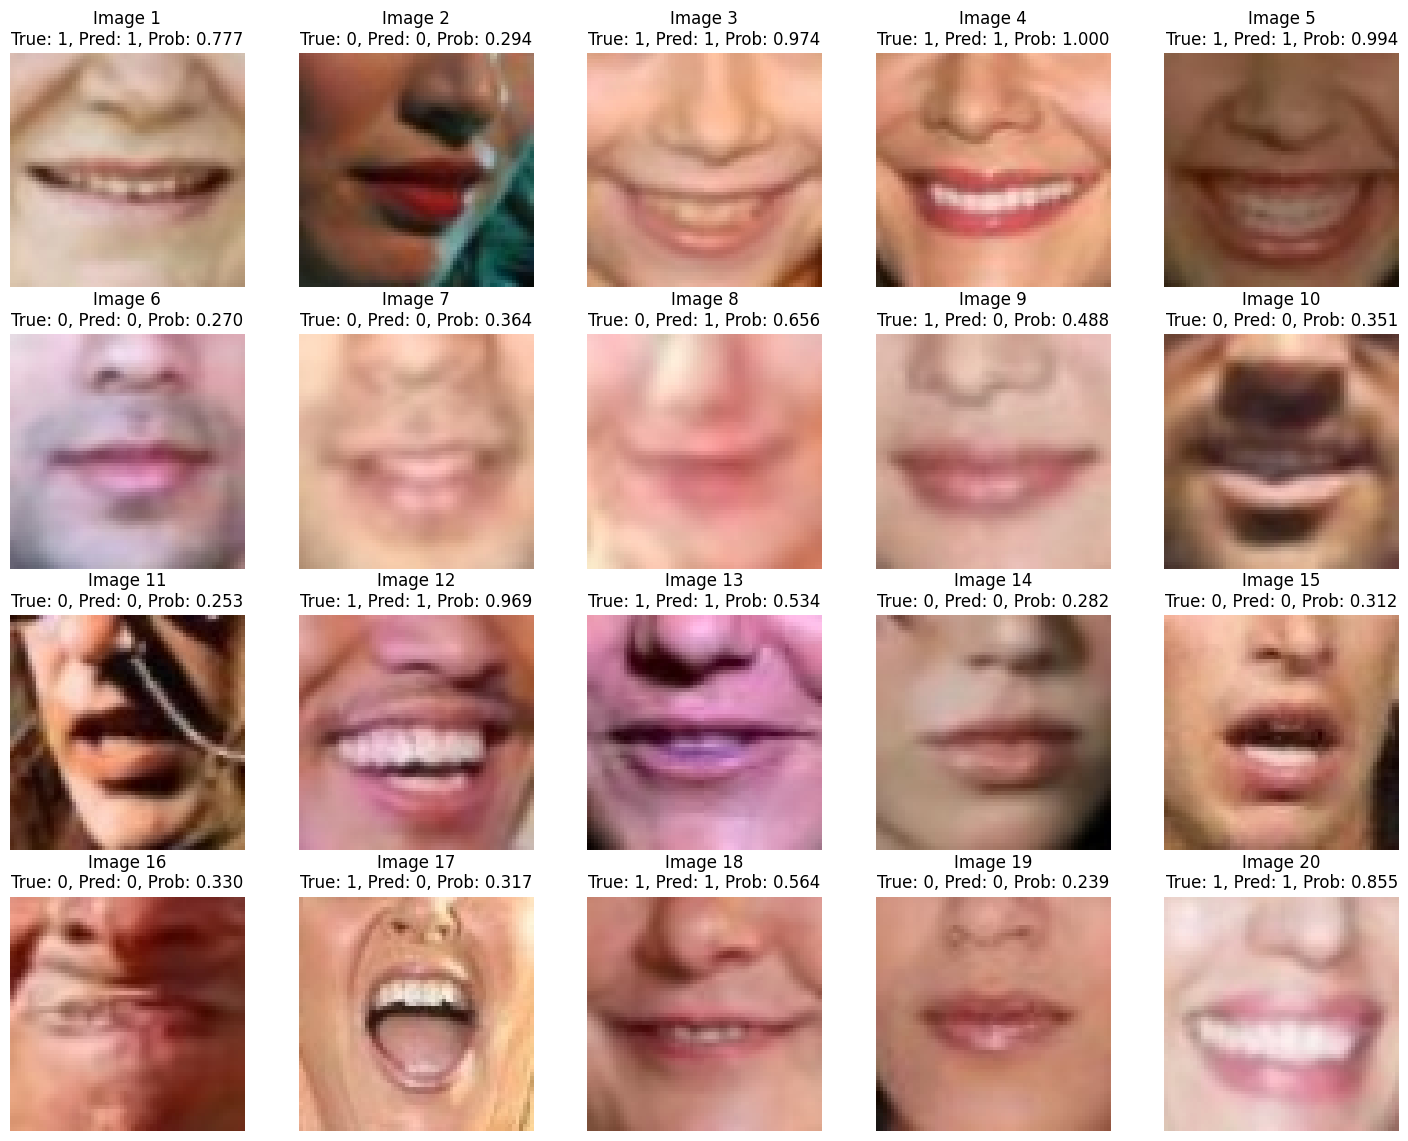

In [ ]:
# Make classification on n=10 samples from the test set with image plot
model_celeba.eval()
n = 20
fig = plt.figure(figsize=(18, 14))
axs = fig.subplots(4, 5)
axs = axs.flatten()

with torch.no_grad():
    for i, (images, labels) in enumerate(test_lips_loader):
        images = images.to(device)
        labels = labels.to(device)
        logits = model_celeba(images).squeeze(1)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()

        for j in range(min(n, images.size(0))):
            img = images[j].cpu().permute(1, 2, 0).numpy() * np.array(IMGNET_STD) + np.array(IMGNET_MEAN)
            axs[j].imshow(np.clip(img, 0, 1))
            axs[j].set_title(f"Image {j+1}\nTrue: {labels[j].item():.0f}, Pred: {preds[j].item():.0f}, Prob: {probs[j].item():.3f}")
            axs[j].axis('off')
        break

plt.show()

Les résultats sur cet échantillon semble être corrects au regard de ce que l'on peut attendre. On se rend compte que la subjectivité liée à cette classification est plutôt bien prise en compte par le modèle. En effet, les images 8, 9 ou 13 sont assez ambigue et ont une probabilité proche de 0.5, là où les sourires francs (4, 5 et 12) ont une probabilité proche de 1, et les visages fermés (2, 6, 14, 19) ont une probabilité proche de 0.

### Évaluation de l'équité

In [ ]:
from tqdm import tqdm

sensitive_attr = ["Male", "Pale_Skin", "Young"]

### Comparaison de l'accuracy par groupe sensible
def evaluate_by_group(model:nn.Module, dataloader:CelebASmilingDataset, sensitive_attr:list[str]):
    raw_data = dict(zip(sensitive_attr, np.zeros((len(sensitive_attr), 2, 4), dtype=int)))  # group -> group_value -> [TP, FP, TN, FN]
    i = 0
    for images, labels in tqdm(dataloader, desc="Evaluating by group", total=len(dataloader)):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()
        for j in range(images.size(0)):
            group_values = dataloader.dataset.attributes.iloc[i][sensitive_attr].values
            group_values = tuple([int(v) for v in group_values])
            pred, true = preds[j].item(), labels[j].item()
            for group, group_value in zip(sensitive_attr, group_values):
                group_value = 1 if group_value == 1 else 0
                if pred == 1 and true == 1:
                    raw_data[group][group_value][0] += 1  # TP
                elif pred == 1 and true == 0:
                    raw_data[group][group_value][1] += 1  # FP
                elif pred == 0 and true == 0:
                    raw_data[group][group_value][2] += 1  # TN
                elif pred == 0 and true == 1:
                    raw_data[group][group_value][3] += 1  # FN
            i += 1
    
    results = {}
    for group in sensitive_attr:
        results[group] = {0: {}, 1: {}}
        for group_value in [0, 1]:
            TP, FP, TN, FN = raw_data[group][group_value]
            n = TP + FP + TN + FN
            acc = (TP + TN) / n
            prec = TP / (TP + FP) if (TP + FP) > 0 else 0
            rec = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
            results[group][group_value] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "n": n, "TP": TP/n, "FP": FP/n, "TN": TN/n, "FN": FN/n}
    return results

        
fairness_smiling_results = evaluate_by_group(model_celeba, test_lips_loader, sensitive_attr)

Evaluating by group: 100%|██████████| 312/312 [00:16<00:00, 18.76it/s]


Group: Male
  Value: 0, Accuracy: 0.854, Precision: 0.898, Recall: 0.836, F1: 0.866, N: 12247, FP: 0.535%, FN: 0.924%
  Value: 1, Accuracy: 0.823, Precision: 0.823, Recall: 0.713, F1: 0.764, N: 7715, FP: 0.616%, FN: 1.151%
Group: Pale_Skin
  Value: 0, Accuracy: 0.842, Precision: 0.879, Recall: 0.798, F1: 0.837, N: 19122, FP: 0.556%, FN: 1.023%
  Value: 1, Accuracy: 0.846, Precision: 0.768, Recall: 0.777, F1: 0.772, N: 840, FP: 0.786%, FN: 0.750%
Group: Young
  Value: 0, Accuracy: 0.808, Precision: 0.851, Recall: 0.758, F1: 0.802, N: 4848, FP: 0.681%, FN: 1.242%
  Value: 1, Accuracy: 0.853, Precision: 0.884, Recall: 0.811, F1: 0.846, N: 15114, FP: 0.529%, FN: 0.938%


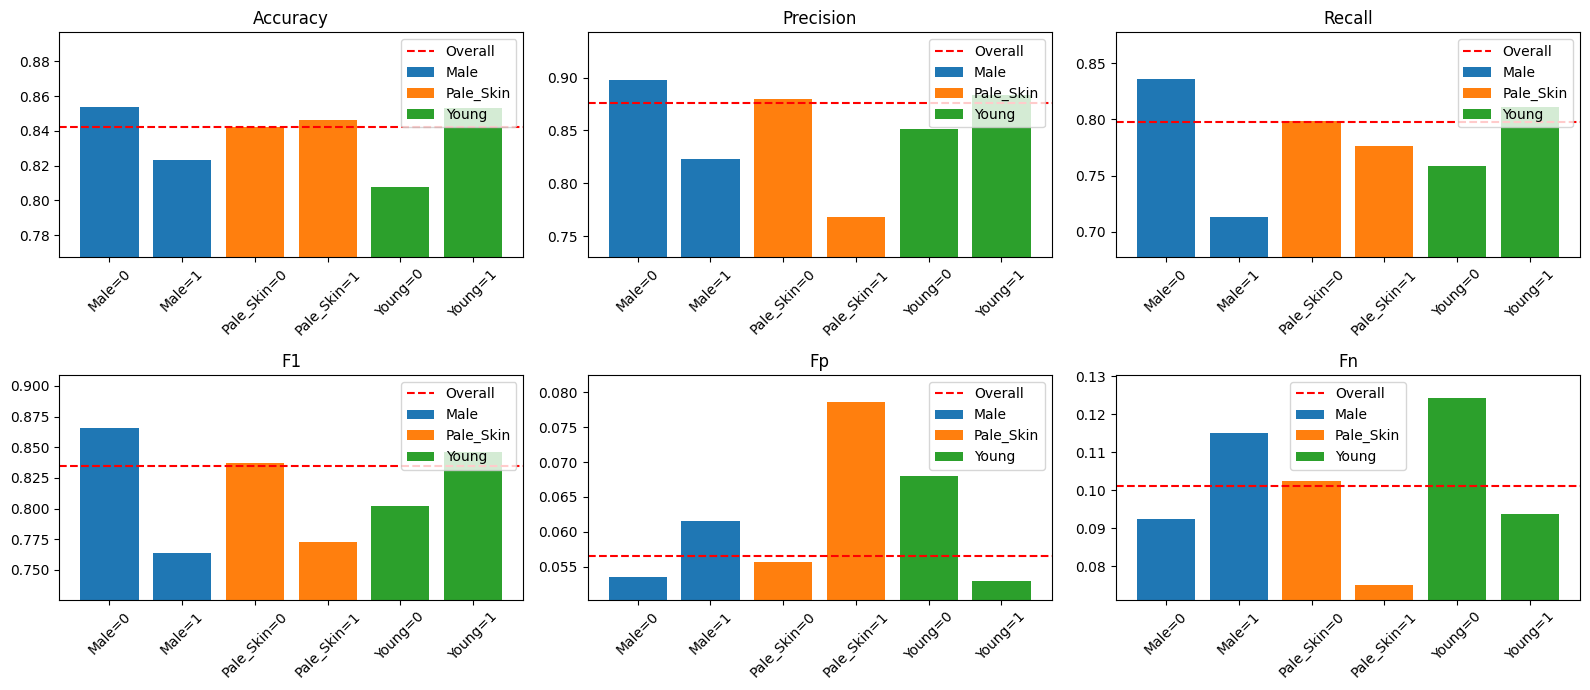

In [14]:
for group in sensitive_attr:
    print(f"Group: {group}")
    for group_value in [0, 1]:
        metrics = fairness_smiling_results[group][group_value]
        print(f"  Value: {group_value}, Accuracy: {metrics['accuracy']:.3f}, Precision: {metrics['precision']:.3f}, Recall: {metrics['recall']:.3f}, F1: {metrics['f1']:.3f}, N: {metrics['n']}, FP: {10*metrics['FP']:.3f}%, FN: {10*metrics['FN']:.3f}%")

# Plot subplots one per metric with all groups on the same plot
metrics = ["accuracy", "precision", "recall", "f1", "FP", "FN"]
fig = plt.figure(figsize=(16, 7))
axs = fig.subplots(2, 3)
axs = axs.flatten()
for i, metric in enumerate(metrics):
    ax = axs[i]
    min_y, max_y = 1, 0
    mean = 0
    for group in sensitive_attr:
        values = [fairness_smiling_results[group][0][metric], fairness_smiling_results[group][1][metric]]
        mean = values[0] * fairness_smiling_results[group][0]["n"] + values[1] * fairness_smiling_results[group][1]["n"]
        mean /= (fairness_smiling_results[group][0]["n"] + fairness_smiling_results[group][1]["n"])
        min_y, max_y = min(min_y, min(values)), max(max_y, max(values))
        ax.bar([f"{group}=0", f"{group}=1"], values, label=group)
    ax.axhline(mean, color='red', linestyle='--', label='Overall')
    ax.set_title(metric.capitalize())
    ax.set_ylim(min_y * 0.95, max_y * 1.05)
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

En conclusion, on observe que les groupes les plus représentés sont souvent aussi les plus justement classifiés:
- les femmes qui représentent 61% des données ont une accuracy de +3pts par rapport aux hommes
- les hommes souriants sont beaucoup plus souvent classés comme non souriants à tord (FN) avec 12 pts d'écart par rapport aux femmes
- de même pour les plus jeunes (qui représentent 76% de l'échantillon) gagnent +5pts par rapport aux plus âgés sur l'accuracy
- les personnes blafardes sont plus souvent classées comme souriantes à tord (FP)